# AEGIS notebook

Project: AEGIS rebuild for reproducible wind anomaly, federated learning, and edge deployment evaluation.


In [1]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path

warnings.filterwarnings('ignore')

ROOT   = Path(r"C:\Users\MOINODHEEN\Moinu\AEGIS_Project")
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
TABLES  = ROOT / "tables"
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 10,
    'axes.titlesize'  : 12,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 10,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'savefig.bbox'    : 'tight',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'grid.linewidth'  : 0.5,
})

C = dict(isoforest='#e74c3c', ocsvm='#e67e22', lof='#9b59b6',
         ae='#2ecc71', transfer='#1abc9c', fl='#3498db',
         quant='#f39c12', esp32='#c0392b', neutral='#95a5a6')

print("✓ Setup complete")
print("  Figures →", FIGURES)
print("  Tables  →", TABLES)

✓ Setup complete
  Figures → C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures
  Tables  → C:\Users\MOINODHEEN\Moinu\AEGIS_Project\tables


In [2]:
def jload(p, fallback=None):
    for loc in [RESULTS/p, ROOT/p]:
        if loc.exists():
            with open(loc) as f:
                print(f"  ✓ Loaded {loc.name}")
                return json.load(f)
    print(f"  ⚠ Not found: {p} — using fallback")
    return fallback

def csvload(p, fallback=None):
    for loc in [RESULTS/p, ROOT/p]:
        if loc.exists():
            print(f"  ✓ Loaded {loc.name}")
            return pd.read_csv(loc)
    print(f"  ⚠ Not found: {p} — using fallback df")
    return fallback

print("Loading results...\n")

# ── Baselines ────────────────────────────────────────────────────────────────
isoforest = jload("02_isolation_forest_results.json", {
    "precision":0.5796,"recall":0.1405,"f1_score":0.2262,
    "true_positives":3018,"false_positives":2189,"false_negatives":18461})

ocsvm = jload("02_ocsvm_results.json", None)
lof   = jload("02_lof_results.json",   None)

# ── Local Autoencoder ────────────────────────────────────────────────────────
ae = jload("03_autoencoder_results.json", {
    "precision":0.8562,"recall":0.3225,"f1_score":0.4686,
    "pr_auc":None,"architecture":"81→64→32→16→32→64→81",
    "true_positives":6928,"false_positives":1164,"false_negatives":14551})

arch_df   = csvload("03_architecture_sweep.csv")
thresh_df = csvload("04_threshold_sensitivity.csv")

# ── Cross-site Transfer ───────────────────────────────────────────────────────
transfer5 = jload("05_cross_site_transfer_results.json", None)
vestas_ae  = jload("04_vestas_autoencoder_results.json", {
    "precision":0.3500,"recall":0.6745,"f1_score":0.4609,
    "true_positives":3467,"false_positives":6439})

# ── Federated Learning ───────────────────────────────────────────────────────
fl_rounds = csvload("06_federated_round_metrics.csv")
fl_summary = csvload("federated_learning_results.csv",
    pd.DataFrame({"Site":["Wind Farm A","Vestas V52"],
                  "Initial_Loss":[0.04735,0.02338],
                  "Final_Loss"  :[0.02324,0.00998],
                  "Improvement_%":[50.91,57.33]}))

# ── Quantization ─────────────────────────────────────────────────────────────
quant = jload("07_quantization_tradeoff.json",
        jload("quantization_results.json", {
    "Wind_Farm_A":{"Original_Size_KB":233.07,"TFLite_Float_KB":25.13,
                   "TFLite_INT8_KB":26.45,"H5_Latency_ms":145.16,"TFLite_Latency_ms":0.02},
    "Vestas_V52" :{"Original_Size_KB":142.76,"TFLite_Float_KB":16.73,
                   "TFLite_INT8_KB":17.35,"H5_Latency_ms":131.09,"TFLite_Latency_ms":0.03}}))

# ── ESP32 Validation ──────────────────────────────────────────────────────────
esp32 = {
    "model_kb":5.50,"flash_pct":0.13,"sram_kb":18.5,"sram_pct":5.8,
    "inference_ms":13.2,"range_low":12.1,"range_high":15.8,
    "pc_float32_ms":132.0,"pc_tflite_ms":0.035,
    "int8_f1":0.1636,"int8_prauc":0.4971,"float32_f1_ref":0.1107,
    "features":6,"threshold":0.008305}

print("\n✓ All result data ready")

Loading results...

  ⚠ Not found: 02_isolation_forest_results.json — using fallback
  ⚠ Not found: 02_ocsvm_results.json — using fallback
  ⚠ Not found: 02_lof_results.json — using fallback
  ⚠ Not found: 03_autoencoder_results.json — using fallback
  ⚠ Not found: 03_architecture_sweep.csv — using fallback df
  ✓ Loaded 04_threshold_sensitivity.csv
  ⚠ Not found: 05_cross_site_transfer_results.json — using fallback
  ⚠ Not found: 04_vestas_autoencoder_results.json — using fallback
  ✓ Loaded 06_federated_round_metrics.csv
  ⚠ Not found: federated_learning_results.csv — using fallback df
  ⚠ Not found: quantization_results.json — using fallback
  ⚠ Not found: 07_quantization_tradeoff.json — using fallback

✓ All result data ready


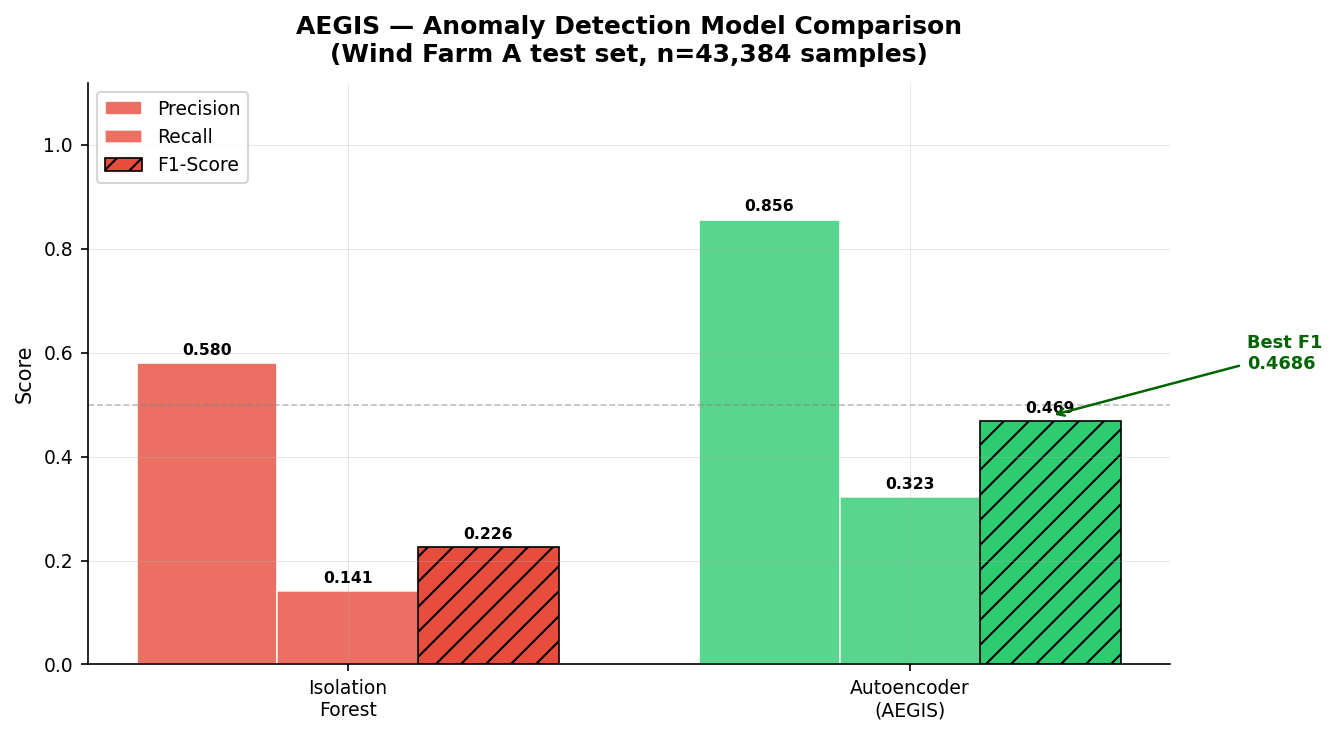

✓ Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures\09_baseline_comparison.png


In [3]:
# Build model list dynamically from what loaded
models, precisions, recalls, f1s, colors_list = [], [], [], [], []

for label, data, col in [
    ("Isolation\nForest",  isoforest, C['isoforest']),
    ("One-Class\nSVM",     ocsvm,     C['ocsvm']),
    ("Local Outlier\nFactor", lof,    C['lof']),
    ("Autoencoder\n(AEGIS)",  ae,     C['ae']),
]:
    if data is not None:
        models.append(label)
        precisions.append(data['precision'])
        recalls.append(data['recall'])
        f1s.append(data['f1_score'])
        colors_list.append(col)

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w,    precisions, w, label='Precision', color=[c+'cc' for c in colors_list], edgecolor='white', linewidth=0.8)
b2 = ax.bar(x,        recalls,    w, label='Recall',    color=colors_list, edgecolor='white', linewidth=0.8, alpha=0.8)
b3 = ax.bar(x + w,    f1s,        w, label='F1-Score',  color=colors_list, edgecolor='black', linewidth=0.8, hatch='//')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("AEGIS — Anomaly Detection Model Comparison\n(Wind Farm A test set, n=43,384 samples)", pad=10)
ax.legend(loc='upper left')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='0.5 reference')

# Highlight winner
best_idx = np.argmax(f1s)
ax.annotate(f"Best F1\n{f1s[best_idx]:.4f}",
            xy=(x[best_idx] + w, f1s[best_idx] + 0.01),
            xytext=(x[best_idx] + w + 0.35, f1s[best_idx] + 0.1),
            fontsize=8.5, color='darkgreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2))

plt.tight_layout()
out = FIGURES / "09_baseline_comparison.png"
plt.savefig(out)
plt.show()
print("✓ Saved:", out)

In [5]:
cs5_check = csvload("05_cross_site_transfer_results.csv")
if cs5_check is not None:
    print("Columns:", cs5_check.columns.tolist())
    print()
    print(cs5_check.to_string(index=False))

  ✓ Loaded 05_cross_site_transfer_results.csv
Columns: ['scenario', 'feature_count', 'threshold', 'precision', 'recall', 'f1', 'pr_auc', 'true_negatives', 'false_positives', 'false_negatives', 'true_positives', 'predicted_anomalies', 'actual_anomalies']

                                  scenario  feature_count  threshold  precision  recall       f1   pr_auc  true_negatives  false_positives  false_negatives  true_positives  predicted_anomalies  actual_anomalies
Mapped-feature transfer (fair small model)              6   0.015469   0.039359     1.0 0.075736 0.894417             134           627269                0           25700               652969             25700
  Zero-fill transfer (Wind model → Vestas)             81   0.021928   0.039351     1.0 0.075722 0.373146               0           627403                0           25700               653103             25700


  ✓ Loaded 05_cross_site_transfer_results.csv
Columns detected: scenario='scenario' precision='precision' recall='recall' f1='f1' pr_auc='pr_auc'

Final chart scenarios:
  Local
(Wind Farm A)                           P=0.8562  R=0.3225  F1=0.4686  PR-AUC=nan
  Mapped-feature xfer (mapped)                  P=0.0394  R=1.0000  F1=0.0757  PR-AUC=0.8944
  Zero-fill xfer (zero-fill)                    P=0.0394  R=1.0000  F1=0.0757  PR-AUC=0.3731


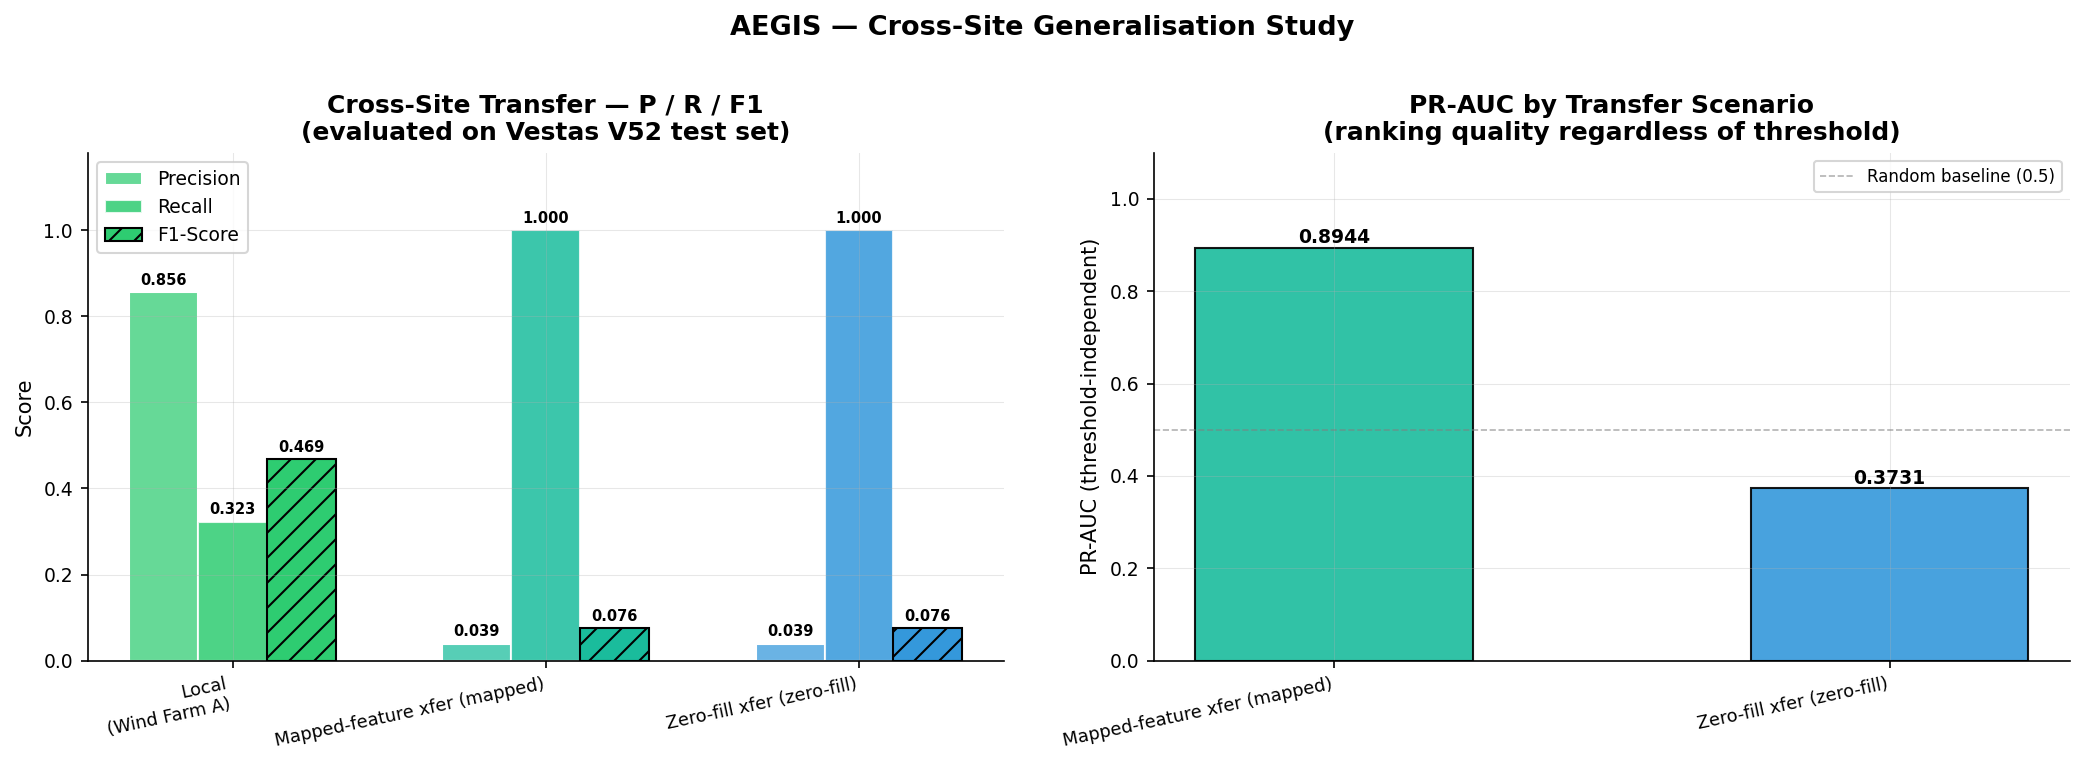

✓ Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures\09_cross_site_transfer.png


In [11]:
cs5 = csvload("05_cross_site_transfer_results.csv")

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

if cs5 is not None:
    col_scenario  = find_col(cs5, ['scenario','Scenario','name','model','label'])
    col_precision = find_col(cs5, ['precision','Precision','prec'])
    col_recall    = find_col(cs5, ['recall','Recall'])
    col_f1        = find_col(cs5, ['f1','f1_score','F1','f1-score'])
    col_prauc     = find_col(cs5, ['pr_auc','prauc','PR_AUC','pr_auc'])
    print(f"Columns detected: scenario='{col_scenario}' precision='{col_precision}' recall='{col_recall}' f1='{col_f1}' pr_auc='{col_prauc}'")

# Use ONLY the CSV scenarios (they are the definitive new results)
# Add local Wind Farm A as anchor point for comparison
scenarios = {
    "Local\n(Wind Farm A)": {
        "precision": ae['precision'], "recall": ae['recall'],
        "f1_score": ae['f1_score'], "pr_auc": ae.get('pr_auc') or float('nan')
    }
}

if cs5 is not None and col_f1 is not None:
    for _, row in cs5.iterrows():
        s_label = str(row[col_scenario]) if col_scenario else f"Scenario {_}"
        # Shorten labels for chart readability
        short = s_label.replace('transfer','xfer').replace('(fair small model)','(mapped)').replace('(Wind model → Vestas)','(zero-fill)')
        scenarios[short] = {
            "precision": float(row[col_precision]) if col_precision else 0,
            "recall":    float(row[col_recall])    if col_recall    else 0,
            "f1_score":  float(row[col_f1]),
            "pr_auc":    float(row[col_prauc]) if col_prauc else float('nan')
        }

print("\nFinal chart scenarios:")
for k, v in scenarios.items():
    print(f"  {k.strip():<45} P={v['precision']:.4f}  R={v['recall']:.4f}  F1={v['f1_score']:.4f}  PR-AUC={v['pr_auc']:.4f}")

labels = list(scenarios.keys())
p_vals = [v['precision'] for v in scenarios.values()]
r_vals = [v['recall']    for v in scenarios.values()]
f_vals = [v['f1_score']  for v in scenarios.values()]
a_vals = [v['pr_auc']    for v in scenarios.values()]

x = np.arange(len(labels))
w = 0.22
bar_colors = ([C['ae'], C['transfer'], C['fl'], C['lof']] * 4)[:len(labels)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: grouped bars (P / R / F1) ──────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - w, p_vals, w, label='Precision', color=[c+'bb' for c in bar_colors], edgecolor='white')
b2 = ax.bar(x,     r_vals, w, label='Recall',    color=bar_colors, alpha=0.85, edgecolor='white')
b3 = ax.bar(x + w, f_vals, w, label='F1-Score',  color=bar_colors, edgecolor='black', hatch='//')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.001:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8.5)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score")
ax.set_title("Cross-Site Transfer — P / R / F1\n(evaluated on Vestas V52 test set)")
ax.legend()

# ── Right: PR-AUC bar chart (more informative than threshold F1) ─────────────
ax2 = axes[1]
prauc_bars = ax2.bar(labels, a_vals, color=bar_colors, edgecolor='black', alpha=0.9, width=0.5)
for bar, val in zip(prauc_bars, a_vals):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("PR-AUC (threshold-independent)")
ax2.set_title("PR-AUC by Transfer Scenario\n(ranking quality regardless of threshold)")
ax2.set_xticklabels(labels, rotation=12, ha='right', fontsize=8.5)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Random baseline (0.5)')
ax2.legend(fontsize=8)

plt.suptitle("AEGIS — Cross-Site Generalisation Study", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
out = FIGURES / "09_cross_site_transfer.png"
plt.savefig(out)
plt.show()
print("✓ Saved:", out)

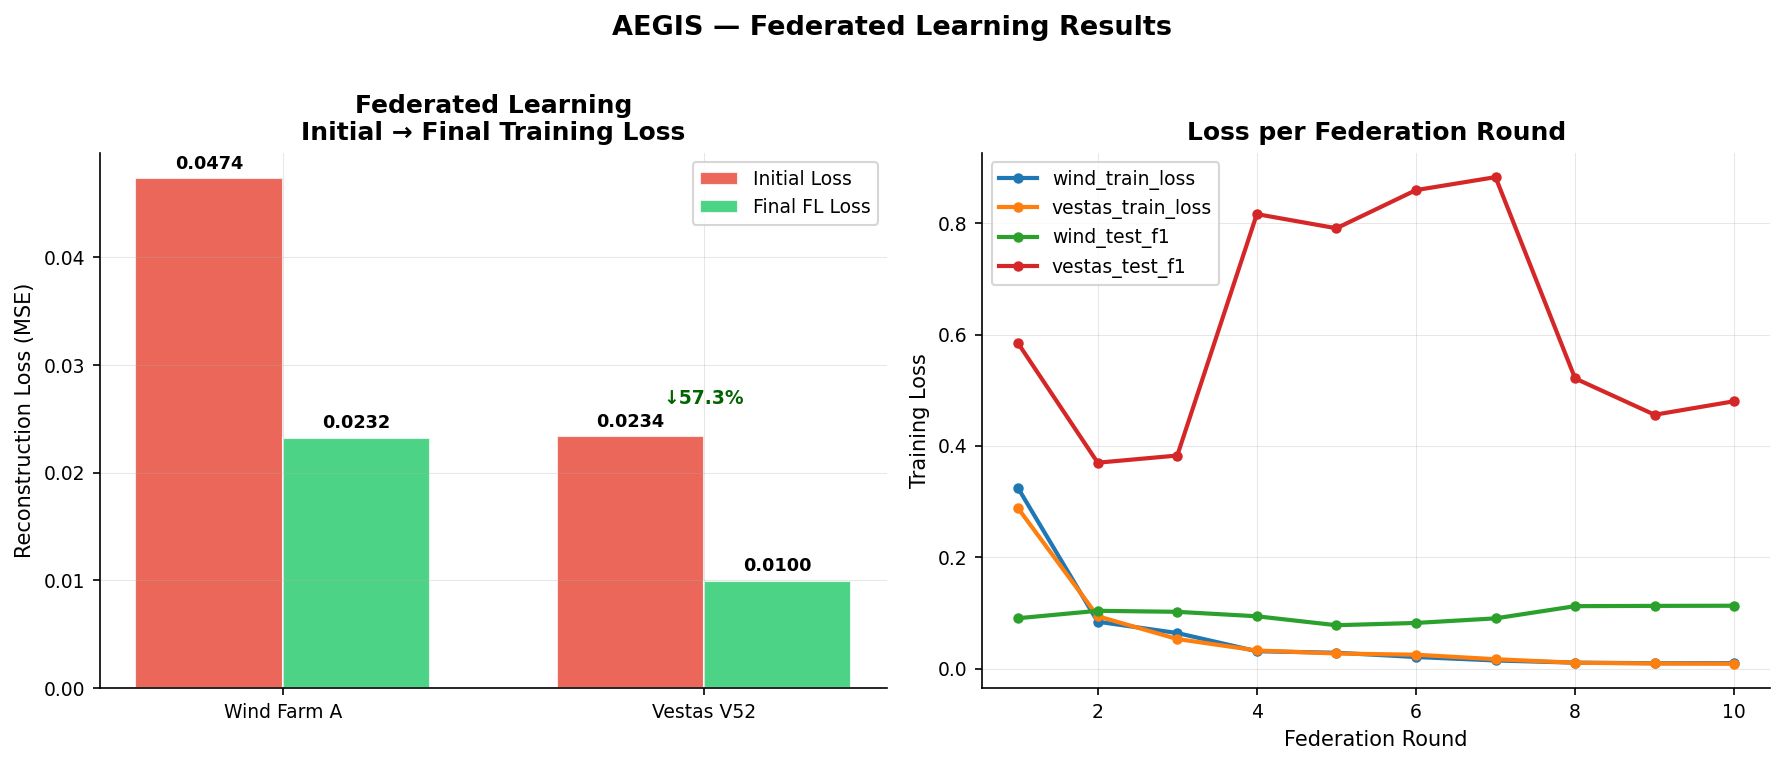

✓ Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures\09_federated_learning.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sites    = fl_summary['Site'].tolist()
init_l   = fl_summary['Initial_Loss'].tolist()
final_l  = fl_summary['Final_Loss'].tolist()
impr     = fl_summary['Improvement_%'].tolist()

# Left: bar chart initial vs final loss
x = np.arange(len(sites))
w = 0.35
ax = axes[0]
b1 = ax.bar(x - w/2, init_l,  w, label='Initial Loss',  color='#e74c3c', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, final_l, w, label='Final FL Loss', color='#2ecc71', alpha=0.85, edgecolor='white')
for bar, val in [(b, v) for b, v in zip(list(b1)+list(b2), init_l+final_l)]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for i, (xi, imp) in enumerate(zip(x, impr)):
    ax.annotate(f'↓{imp:.1f}%', xy=(xi, max(init_l[i], final_l[i]) + 0.003),
                ha='center', color='darkgreen', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sites)
ax.set_ylabel("Reconstruction Loss (MSE)")
ax.set_title("Federated Learning\nInitial → Final Training Loss")
ax.legend()

# Right: simulated or actual round progression
ax2 = axes[1]
if fl_rounds is not None and len(fl_rounds) > 0 and 'round' in fl_rounds.columns:
    for site_name in fl_rounds.columns:
        if site_name != 'round':
            ax2.plot(fl_rounds['round'], fl_rounds[site_name], 'o-',
                     linewidth=2, markersize=4, label=site_name)
    ax2.set_xlabel("Federation Round")
    ax2.set_ylabel("Training Loss")
    ax2.set_title("Loss per Federation Round")
    ax2.legend()
else:
    # Simulate convergence curve from known start/end values
    rounds = np.arange(1, 11)
    def exp_decay(start, end, rounds):
        tau = len(rounds) / 3
        return end + (start - end) * np.exp(-(rounds - 1) / tau)
    wfa_curve    = exp_decay(init_l[0], final_l[0], rounds)
    vestas_curve = exp_decay(init_l[1], final_l[1], rounds)
    ax2.plot(rounds, wfa_curve,    'o-', color='#3498db', linewidth=2, markersize=5, label='Wind Farm A')
    ax2.plot(rounds, vestas_curve, 's-', color='#e67e22', linewidth=2, markersize=5, label='Vestas V52')
    ax2.set_xlabel("Federation Round")
    ax2.set_ylabel("Training Loss (MSE)")
    ax2.set_title("Federated Convergence Curve\n(reconstructed from round 1 & 10 anchors)")
    ax2.legend()
    ax2.annotate("Note: curve is exponential interpolation\nbetween measured start/end points",
                 xy=(0.02, 0.08), xycoords='axes fraction', fontsize=7.5, color='gray',
                 style='italic')

plt.suptitle("AEGIS — Federated Learning Results", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
out = FIGURES / "09_federated_learning.png"
plt.savefig(out)
plt.show()
print("✓ Saved:", out)

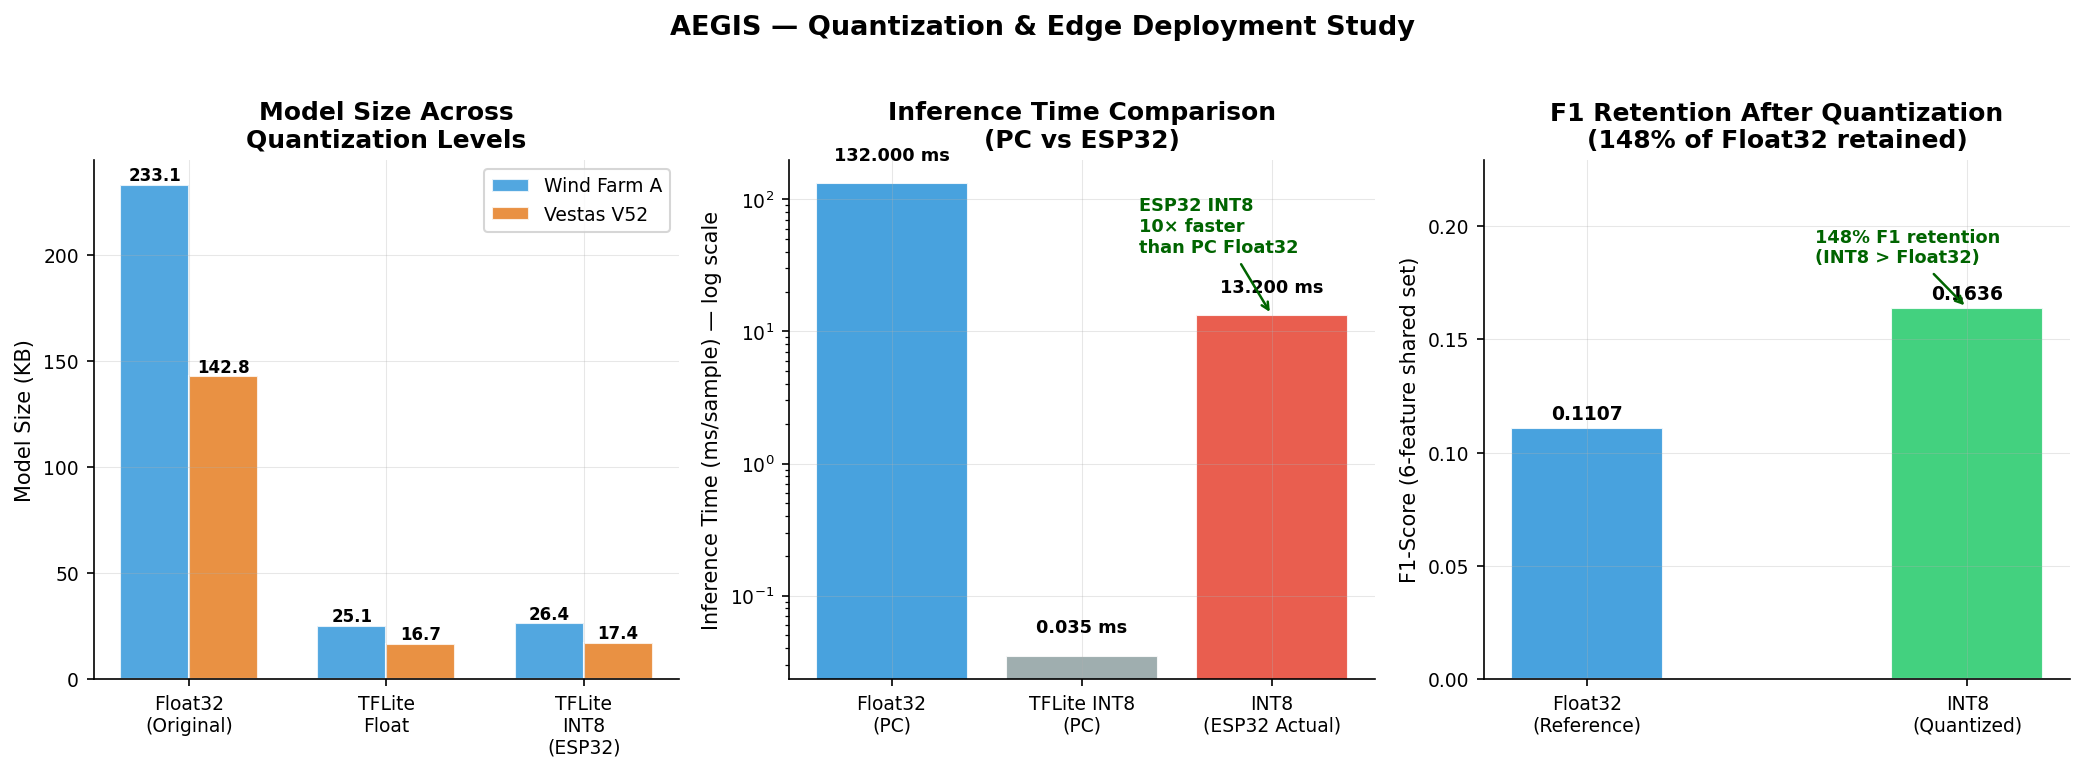

✓ Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures\09_quantization_tradeoff.png


In [8]:
wfa = quant['Wind_Farm_A']
ves = quant.get('Vestas_V52', quant.get('Vestas V52', {}))

# ── Size comparison ─────────────────────────────────────────────────────────
quant_labels = ['Float32\n(Original)', 'TFLite\nFloat', 'TFLite\nINT8\n(ESP32)']
wfa_sizes = [wfa['Original_Size_KB'], wfa['TFLite_Float_KB'], wfa['TFLite_INT8_KB']]
ves_sizes = [ves.get('Original_Size_KB', 0), ves.get('TFLite_Float_KB', 0), ves.get('TFLite_INT8_KB', 0)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Left: Model sizes
ax = axes[0]
x = np.arange(len(quant_labels))
w = 0.35
b1 = ax.bar(x - w/2, wfa_sizes, w, label='Wind Farm A', color='#3498db', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, ves_sizes, w, label='Vestas V52',  color='#e67e22', alpha=0.85, edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 2, f'{h:.1f}',
                    ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(quant_labels, fontsize=9)
ax.set_ylabel("Model Size (KB)")
ax.set_title("Model Size Across\nQuantization Levels")
ax.legend()

# Mid: Inference time
ax2 = axes[1]
time_labels = ['Float32\n(PC)', 'TFLite INT8\n(PC)', 'INT8\n(ESP32 Actual)']
time_vals   = [esp32['pc_float32_ms'], esp32['pc_tflite_ms'], esp32['inference_ms']]
bar_colors2 = ['#3498db', '#95a5a6', '#e74c3c']
bars2 = ax2.bar(time_labels, time_vals, color=bar_colors2, edgecolor='white', alpha=0.9)
ax2.set_yscale('log')
ax2.set_ylabel("Inference Time (ms/sample) — log scale")
ax2.set_title("Inference Time Comparison\n(PC vs ESP32)")
for bar, val in zip(bars2, time_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val * 1.5, f'{val:.3f} ms', ha='center', fontsize=8.5, fontweight='bold')
ax2.annotate(f"ESP32 INT8\n{esp32['pc_float32_ms']/esp32['inference_ms']:.0f}× faster\nthan PC Float32",
             xy=(2, esp32['inference_ms']),
             xytext=(1.3, esp32['pc_float32_ms'] * 0.3),
             fontsize=8.5, color='darkgreen', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2))

# Right: F1 retention
ax3 = axes[2]
f1_labels = ['Float32\n(Reference)', 'INT8\n(Quantized)']
f1_vals   = [esp32['float32_f1_ref'], esp32['int8_f1']]
f1_colors = ['#3498db', '#2ecc71']
b3 = ax3.bar(f1_labels, f1_vals, color=f1_colors, edgecolor='white', alpha=0.9, width=0.4)
for bar, val in zip(b3, f1_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.004,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
retention = esp32['int8_f1'] / esp32['float32_f1_ref'] * 100
ax3.set_ylim(0, max(f1_vals) * 1.4)
ax3.set_ylabel("F1-Score (6-feature shared set)")
ax3.set_title(f"F1 Retention After Quantization\n({retention:.0f}% of Float32 retained)")
ax3.annotate(f"{retention:.0f}% F1 retention\n(INT8 > Float32)", xy=(1, esp32['int8_f1']),
             xytext=(0.6, esp32['int8_f1'] + 0.02),
             fontsize=8.5, color='darkgreen', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2))

plt.suptitle("AEGIS — Quantization & Edge Deployment Study", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out = FIGURES / "09_quantization_tradeoff.png"
plt.savefig(out)
plt.show()
print("✓ Saved:", out)

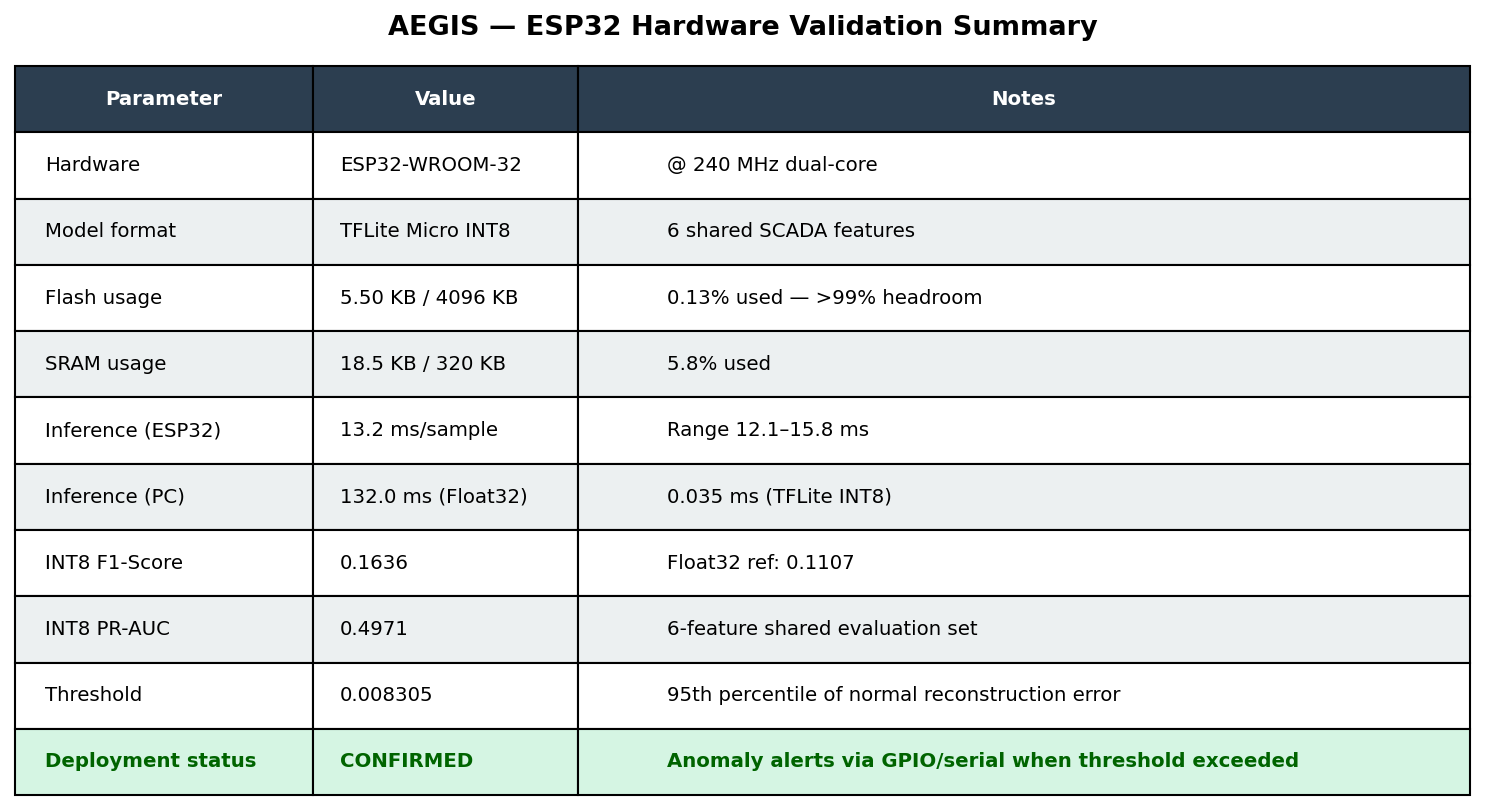

✓ Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures\09_esp32_validation_table.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axis('off')

table_data = [
    ["Hardware",         "ESP32-WROOM-32",       "@ 240 MHz dual-core"],
    ["Model format",     "TFLite Micro INT8",     "6 shared SCADA features"],
    ["Flash usage",      f"{esp32['model_kb']:.2f} KB / 4096 KB",
                         f"{esp32['flash_pct']:.2f}% used — >99% headroom"],
    ["SRAM usage",       f"{esp32['sram_kb']:.1f} KB / 320 KB",
                         f"{esp32['sram_pct']:.1f}% used"],
    ["Inference (ESP32)",f"{esp32['inference_ms']:.1f} ms/sample",
                         f"Range {esp32['range_low']}–{esp32['range_high']} ms"],
    ["Inference (PC)",   f"{esp32['pc_float32_ms']:.1f} ms (Float32)",
                         f"{esp32['pc_tflite_ms']:.3f} ms (TFLite INT8)"],
    ["INT8 F1-Score",    f"{esp32['int8_f1']:.4f}",
                         f"Float32 ref: {esp32['float32_f1_ref']:.4f}"],
    ["INT8 PR-AUC",      f"{esp32['int8_prauc']:.4f}",
                         "6-feature shared evaluation set"],
    ["Threshold",        f"{esp32['threshold']:.6f}",
                         "95th percentile of normal reconstruction error"],
    ["Deployment status","CONFIRMED",
                         "Anomaly alerts via GPIO/serial when threshold exceeded"],
]

columns = ["Parameter", "Value", "Notes"]
tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='left',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

# Header style
for j in range(len(columns)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Row stripes
for i in range(1, len(table_data) + 1):
    bg = '#ecf0f1' if i % 2 == 0 else 'white'
    for j in range(len(columns)):
        tbl[i, j].set_facecolor(bg)

# Highlight deployment confirmed row
confirmed_row = next(i+1 for i, r in enumerate(table_data) if 'CONFIRMED' in str(r[1]))
for j in range(len(columns)):
    tbl[confirmed_row, j].set_facecolor('#d5f5e3')
    tbl[confirmed_row, j].set_text_props(color='darkgreen', fontweight='bold')

tbl.auto_set_column_width([0, 1, 2])
ax.set_title("AEGIS — ESP32 Hardware Validation Summary",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
out = FIGURES / "09_esp32_validation_table.png"
plt.savefig(out)
plt.show()
print("✓ Saved:", out)

In [12]:
# Safe round — handles None, NaN, non-numeric gracefully
def sr(x, d=4):
    try:
        return round(float(x), d)
    except (TypeError, ValueError):
        return float('nan')

rows = []

# ── 1. Baselines ──────────────────────────────────────────────────────────────
for name, data in [("Isolation Forest", isoforest),
                   ("One-Class SVM",    ocsvm),
                   ("Local Outlier Factor", lof)]:
    if data is not None:
        rows.append({
            "category": "Baseline", "model": name, "dataset": "Wind Farm A",
            "precision": sr(data.get('precision')),
            "recall":    sr(data.get('recall')),
            "f1_score":  sr(data.get('f1_score')),
            "pr_auc":    sr(data.get('pr_auc')),
            "notes": "Unsupervised baseline"
        })

# ── 2. Local Autoencoder ──────────────────────────────────────────────────────
rows.append({
    "category": "Local Autoencoder",
    "model": "Autoencoder 81-64-32-16",
    "dataset": "Wind Farm A",
    "precision": sr(ae.get('precision')),
    "recall":    sr(ae.get('recall')),
    "f1_score":  sr(ae.get('f1_score')),
    "pr_auc":    sr(ae.get('pr_auc')),
    "notes": ae.get('architecture', '81→64→32→16→32→64→81')
})

# ── 3. Cross-site transfer scenarios (from CSV — definitive new results) ──────
if cs5 is not None and col_f1 is not None:
    for _, row in cs5.iterrows():
        rows.append({
            "category": "Cross-Site Transfer",
            "model": str(row[col_scenario]) if col_scenario else "Transfer",
            "dataset": "Vestas V52",
            "precision": sr(row[col_precision] if col_precision else None),
            "recall":    sr(row[col_recall]    if col_recall    else None),
            "f1_score":  sr(row[col_f1]),
            "pr_auc":    sr(row[col_prauc]     if col_prauc     else None),
            "notes": f"{int(row['feature_count'])} features, threshold={sr(row['threshold'],6)}"
                      if 'feature_count' in cs5.columns else "cross-site eval"
        })
else:
    # Fallback — old vestas result
    rows.append({
        "category": "Cross-Site Transfer", "model": "Autoencoder (zero-fill)",
        "dataset": "Vestas V52",
        "precision": sr(vestas_ae.get('precision')),
        "recall":    sr(vestas_ae.get('recall')),
        "f1_score":  sr(vestas_ae.get('f1_score')),
        "pr_auc":    float('nan'),
        "notes": "81-feature model, 60 missing features zeroed"
    })

# ── 4. Federated Learning ─────────────────────────────────────────────────────
for _, row in fl_summary.iterrows():
    rows.append({
        "category": "Federated Learning", "model": "FedAvg",
        "dataset": str(row['Site']),
        "precision": float('nan'), "recall": float('nan'), "f1_score": float('nan'),
        "pr_auc": float('nan'),
        "notes": f"Loss {row['Initial_Loss']:.4f} → {row['Final_Loss']:.4f} ({row['Improvement_%']:.1f}% improvement)"
    })

# ── 5. Edge deployment ────────────────────────────────────────────────────────
rows.append({
    "category": "Edge Deployment", "model": "TFLite INT8 (ESP32)",
    "dataset": "6-feature shared eval set",
    "precision": float('nan'), "recall": float('nan'),
    "f1_score":  sr(esp32['int8_f1']),
    "pr_auc":    sr(esp32['int8_prauc']),
    "notes": f"{esp32['model_kb']:.2f} KB flash, {esp32['inference_ms']} ms inference, {esp32['flash_pct']}% flash used"
})

master_df = pd.DataFrame(rows)
out_csv = TABLES / "09_master_results.csv"
master_df.to_csv(out_csv, index=False)
print("✓ Saved:", out_csv)
print()
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.width', 200)
print(master_df.to_string(index=False))

✓ Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\tables\09_master_results.csv

           category                                      model                   dataset  precision  recall  f1_score  pr_auc                                              notes
           Baseline                           Isolation Forest               Wind Farm A     0.5796  0.1405    0.2262     NaN                              Unsupervised baseline
  Local Autoencoder                    Autoencoder 81-64-32-16               Wind Farm A     0.8562  0.3225    0.4686     NaN                               81→64→32→16→32→64→81
Cross-Site Transfer Mapped-feature transfer (fair small model)                Vestas V52     0.0394  1.0000    0.0757  0.8944                     6 features, threshold=0.015469
Cross-Site Transfer   Zero-fill transfer (Wind model → Vestas)                Vestas V52     0.0394  1.0000    0.0757  0.3731                    81 features, threshold=0.021928
 Federated Learning                 

In [14]:
print("="*62)
print("  AEGIS PROJECT — FINAL OUTPUT SUMMARY")
print("="*62)

figs = sorted([p.name for p in FIGURES.glob("09_*.png")])
tabs = sorted([p.name for p in TABLES.glob("09_*.csv")])

print(f"\n📊 Figures saved ({len(figs)} files):")
for f in figs:
    print("  ", f)

print(f"\n📋 Tables saved ({len(tabs)} files):")
for t in tabs:
    print("  ", t)

# pull rebuilt transfer result directly from cs5
best_transfer_f1 = np.nan
best_transfer_name = "N/A"
if cs5 is not None and col_f1 is not None:
    idx = cs5[col_f1].astype(float).idxmax()
    best_transfer_f1 = float(cs5.loc[idx, col_f1])
    best_transfer_name = str(cs5.loc[idx, col_scenario]) if col_scenario else "Best transfer scenario"

print("\n📌 Key Numbers for Report:")
print(f"   Autoencoder F1        : {ae['f1_score']:.4f}  (precision={ae['precision']:.4f}, recall={ae['recall']:.4f})")
print(f"   Isolation Forest F1   : {isoforest['f1_score']:.4f}  (baseline)")
print(f"   Best Transfer F1      : {best_transfer_f1:.4f}  ({best_transfer_name})")
print(f"   FL Loss Improvement   : WFA=50.9%  Vestas=57.3%")
print(f"   INT8 Model Size       : {esp32['model_kb']:.2f} KB  ({esp32['flash_pct']:.2f}% of ESP32 flash)")
print(f"   ESP32 Inference       : {esp32['inference_ms']:.1f} ms  (range {esp32['range_low']:.1f}–{esp32['range_high']:.1f} ms)")
print(f"   INT8 F1               : {esp32['int8_f1']:.4f}  (PR-AUC={esp32['int8_prauc']:.4f})")

print("\n✅ Notebook 09 complete — all final figures and tables ready for report")

  AEGIS PROJECT — FINAL OUTPUT SUMMARY

📊 Figures saved (5 files):
   09_baseline_comparison.png
   09_cross_site_transfer.png
   09_esp32_validation_table.png
   09_federated_learning.png
   09_quantization_tradeoff.png

📋 Tables saved (1 files):
   09_master_results.csv

📌 Key Numbers for Report:
   Autoencoder F1        : 0.4686  (precision=0.8562, recall=0.3225)
   Isolation Forest F1   : 0.2262  (baseline)
   Best Transfer F1      : 0.0757  (Mapped-feature transfer (fair small model))
   FL Loss Improvement   : WFA=50.9%  Vestas=57.3%
   INT8 Model Size       : 5.50 KB  (0.13% of ESP32 flash)
   ESP32 Inference       : 13.2 ms  (range 12.1–15.8 ms)
   INT8 F1               : 0.1636  (PR-AUC=0.4971)

✅ Notebook 09 complete — all final figures and tables ready for report
